In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [ ]:
# LOADING THE DATA

df = pd.read_csv(r"/content/sales_data_sample.csv", encoding_errors="replace")

In [ ]:
#Inspecting the data
print(df.head())
print(df.shape)
print(df.info())
print(df.describe(include="all").T)
print(df.isna().sum())
print("Duplicates:",df.duplicated().sum())

   ORDERNUMBER  QUANTITYORDERED  PRICEEACH  ORDERLINENUMBER    SALES  \
0        10107               30      95.70                2  2871.00   
1        10121               34      81.35                5  2765.90   
2        10134               41      94.74                2  3884.34   
3        10145               45      83.26                6  3746.70   
4        10159               49     100.00               14  5205.27   

         ORDERDATE   STATUS  QTR_ID  MONTH_ID  YEAR_ID  ...  \
0   2/24/2003 0:00  Shipped       1         2     2003  ...   
1    5/7/2003 0:00  Shipped       2         5     2003  ...   
2    7/1/2003 0:00  Shipped       3         7     2003  ...   
3   8/25/2003 0:00  Shipped       3         8     2003  ...   
4  10/10/2003 0:00  Shipped       4        10     2003  ...   

                    ADDRESSLINE1  ADDRESSLINE2           CITY STATE  \
0        897 Long Airport Avenue           NaN            NYC    NY   
1             59 rue de l'Abbaye           NaN

In [ ]:
#Cleaning:

df["ORDERDATE"] = pd.to_datetime(df['ORDERDATE'], errors='coerce')

for col in df.select_dtypes('object').columns:
  df[col] = df[col].apply(lambda x: x.strip() if isinstance (x, str) else x)

df["Year"] = df["ORDERDATE"].dt.year
df["Month"] = df["ORDERDATE"].dt.month
df["Month_Name"] = df["ORDERDATE"].dt.month_name

In [ ]:
# DESCRIPTIVE ANALYSIS

print("TOTAL SALES:",df["SALES"].sum())
print("Orders",df["ORDERNUMBER"].nunique())
print("Customers",df['CUSTOMERNAME'].nunique())
print("Products",df["PRODUCTCODE"].nunique())

print(df.groupby("Year")["SALES"].agg(['sum','mean','count']).sort_values('sum', ascending=False))

print(df.groupby("COUNTRY")["SALES"].sum().sort_values(ascending=False).head(10))

print(df.groupby('DEALSIZE')["SALES"].agg(['sum','mean','count']))

print(df.groupby("STATUS")["SALES"].agg(['sum','count']))

#OUTLIERS USING IQR

q1=df["SALES"].quantile(0.25)
q3=df["SALES"].quantile(0.75)

IQR=q3-q1

#outliers=df[df["SALES"]<q1-1.5*IQR | (df["SALES"]> q3+1.5*IQR)]
outliers=df[(df["SALES"]<q1-1.5*IQR)|(df["SALES"] > q3 + 1.5 * IQR)]

print("Sales Outliers:",len(outliers))

TOTAL SALES: 10032628.85
Orders 307
Customers 92
Products 109
             sum         mean  count
Year                                
2004  4724162.60  3512.388550   1345
2003  3516979.54  3516.979540   1000
2005  1791486.71  3747.880146    478
COUNTRY
USA          3627982.83
Spain        1215686.92
France       1110916.52
Australia     630623.10
UK            478880.46
Italy         374674.31
Finland       329581.91
Norway        307463.70
Singapore     288488.41
Denmark       245637.15
Name: SALES, dtype: float64
                 sum         mean  count
DEALSIZE                                
Large     1302119.26  8293.753248    157
Medium    6087432.24  4398.433699   1384
Small     2643077.35  2061.682800   1282
                   sum  count
STATUS                       
Cancelled    194487.48     60
Disputed      72212.86     14
In Process   144729.96     41
On Hold      178979.19     44
Resolved     150718.28     47
Shipped     9291501.08   2617
Sales Outliers: 81


In [ ]:
#Correlation:

print(df.select_dtypes('number').corr()["SALES"].sort_values(ascending=False))

SALES              1.000000
PRICEEACH          0.657841
MSRP               0.635239
QUANTITYORDERED    0.551426
ORDERNUMBER        0.039919
YEAR_ID            0.035647
Year               0.035647
QTR_ID            -0.006796
MONTH_ID          -0.009605
Month             -0.009605
ORDERLINENUMBER   -0.058400
Name: SALES, dtype: float64


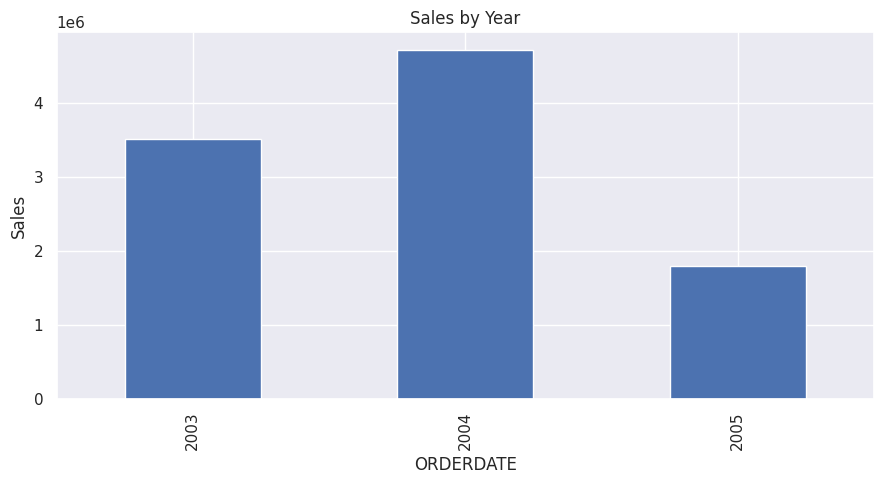

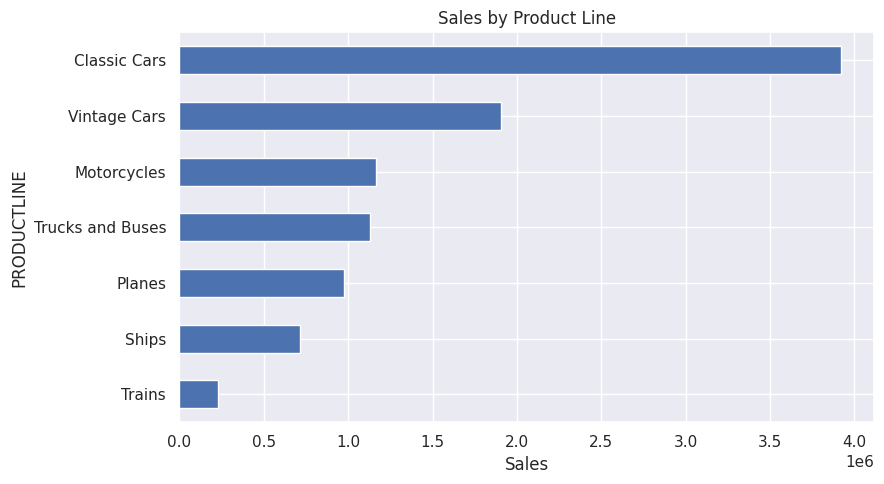

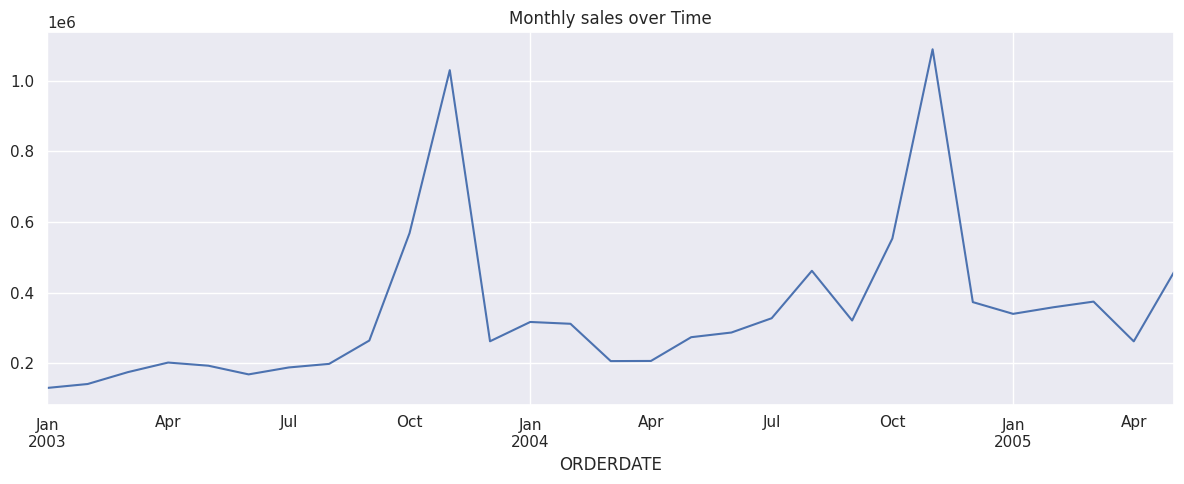

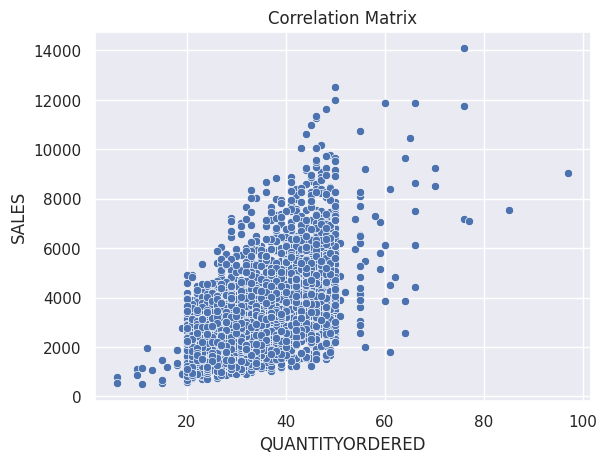

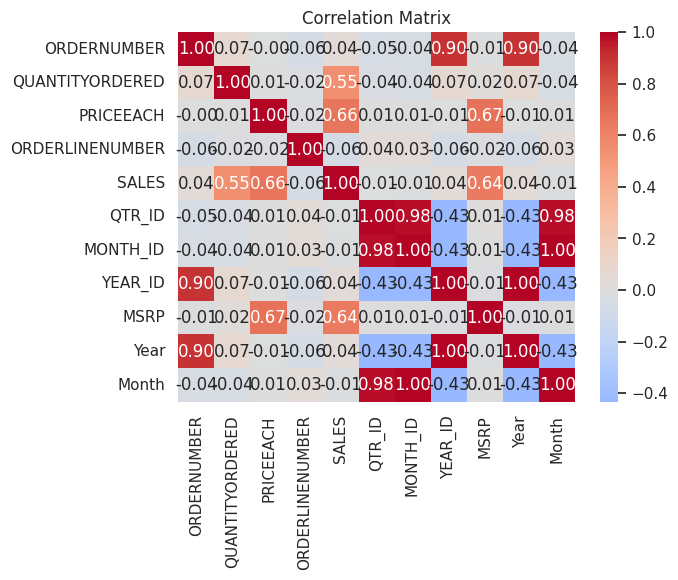

In [ ]:
#VISUALIZATION

sns.set_theme()

df.groupby(df["ORDERDATE"].dt.year)["SALES"].sum().plot(kind='bar',figsize=(9,5),title="Sales by Year")

plt.ylabel("Sales")
plt.tight_layout()
plt.show()

df.groupby("PRODUCTLINE")["SALES"].sum().sort_values().plot(kind="barh",figsize=(9,5),title="Sales by Product Line")
plt.xlabel("Sales")
plt.tight_layout()
plt.show()

monthly=df.groupby(df["ORDERDATE"].dt.to_period("M"))["SALES"].sum()
monthly.plot(figsize=(12,5),title="Monthly sales over Time")
plt.tight_layout()
plt.show()

sns.scatterplot(data=df,x="QUANTITYORDERED",y="SALES")
plt.title("Correlation Matrix")
plt.show()

sns.heatmap(df.select_dtypes("number").corr(),annot=True,fmt=".2f",cmap="coolwarm",center=0)
plt.title("Correlation Matrix")
plt.show()